## Görev 5 

In [147]:
# İnternetten bir Türkçe isim listesi bul (açık kaynak listeler var, GitHub'da arayabilirsin) ve iki modeli de bu veriyle tekrar koştur. Alfabeyi Türkçe karakterlerle genişlet (ç, ğ, ı, ö, ş, ü). Modelin ürettiği isimlerden örnekleri ve loss'u göster.

In [148]:
# https://github.com/tarikbahar/Turkish_names_and_surnames_dataset/tree/master

In [149]:
import torch

In [150]:
words=  open("turkce_isimler_listesi.txt", "rb").read() #utf-16 ile encode edilmiş 
words[:10]

b'\xff\xfeA\x00b\x00a\x00,\x00'

In [151]:
text = words.decode("utf-16") #çözüyoruz 
words = [l.strip() for l in text.splitlines() if l.strip()]  #satır satır liste haline alır
print('words num:',len(words))
print(words[:10])

words num: 3493
['Aba,k', 'Abadan,k', 'Abak,e', 'Abaka,e', 'Abakan,e', 'Abakay,e', 'Abar,e', 'Abasıyanık,e', 'Abaş,k', 'Abaşkatun,k']


In [152]:
names = []
for w in words:
    parts = w.split(',')
    names.append(parts[0])

print(names[:10])

['Aba', 'Abadan', 'Abak', 'Abaka', 'Abakan', 'Abakay', 'Abar', 'Abasıyanık', 'Abaş', 'Abaşkatun']


In [153]:
def lowercase(s):
    s = s.replace('İ', 'i').replace('I', 'ı')
    return s.lower()

names_lower = [lowercase(n) for n in names]
print(names_lower[:10])

['aba', 'abadan', 'abak', 'abaka', 'abakan', 'abakay', 'abar', 'abasıyanık', 'abaş', 'abaşkatun']


In [154]:
names_unique = sorted(set(names_lower))
print('unique names:', len(names_unique))

unique names: 3114


In [155]:
chars = sorted(set(''.join(names_unique)))
print(chars)

[' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y', 'z', 'â', 'ç', 'ö', 'ü', 'ğ', 'ı', 'ş']


In [156]:
names_clean = [n.replace('â', 'a') for n in names_unique] # şapkalı a ların yerine a koyuyoruz  
names_clean = [n for n in names_clean if ' ' not in n] # iki isimli olan ümmü gülsüm ali rıza gibi isimleri çıkarıyoruz
names_clean = sorted(set(names_clean)) # set ile benzersiz isimleri alıyoruz ve tekrar alfabeye göre sıralıyoruz 

In [157]:
chars = sorted(set(''.join(names_clean)))
print('alfabe:', chars)
print('karakter sayısı:', len(chars))
print('toplam isim sayısı:', len(names_clean))
print('örnek isimler:', names_clean[:15])

alfabe: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y', 'z', 'ç', 'ö', 'ü', 'ğ', 'ı', 'ş']
karakter sayısı: 29
toplam isim sayısı: 3110
örnek isimler: ['aba', 'abadan', 'abak', 'abaka', 'abakan', 'abakay', 'abar', 'abasıyanık', 'abay', 'abaza', 'abaş', 'abaşkatun', 'abbas', 'abdal', 'abdan']


In [158]:
words = names_clean

In [159]:
print(min(len(w) for w in words))
print(max(len(w) for w in words))

2
17


In [160]:
for w in words[:2]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        print (ch1, ch2)

. a
a b
b a
a .
. a
a b
b a
a d
d a
a n
n .


In [161]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        biagram  = (ch1 , ch2)
        b[biagram] = b.get(biagram, 0) + 1 

sorted(b.items(), key= lambda kv: -kv[1])[:12] # en çok n ile bitmiş names.txt de en çok n ile bitmişti.

[(('n', '<E>'), 657),
 (('<S>', 'k'), 497),
 (('a', 'n'), 471),
 (('<S>', 'a'), 443),
 (('k', '<E>'), 406),
 (('k', 'a'), 405),
 (('a', 'r'), 395),
 (('<S>', 'b'), 392),
 (('<S>', 't'), 360),
 (('a', 'y'), 334),
 (('a', '<E>'), 298),
 (('b', 'a'), 278)]

In [162]:
stoi  = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'y': 22,
 'z': 23,
 'ç': 24,
 'ö': 25,
 'ü': 26,
 'ğ': 27,
 'ı': 28,
 'ş': 29,
 '.': 0}

In [163]:
N = torch.zeros((30, 30), dtype=torch.int32)

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] +=1

(np.float64(-0.5), np.float64(29.5), np.float64(29.5), np.float64(-0.5))

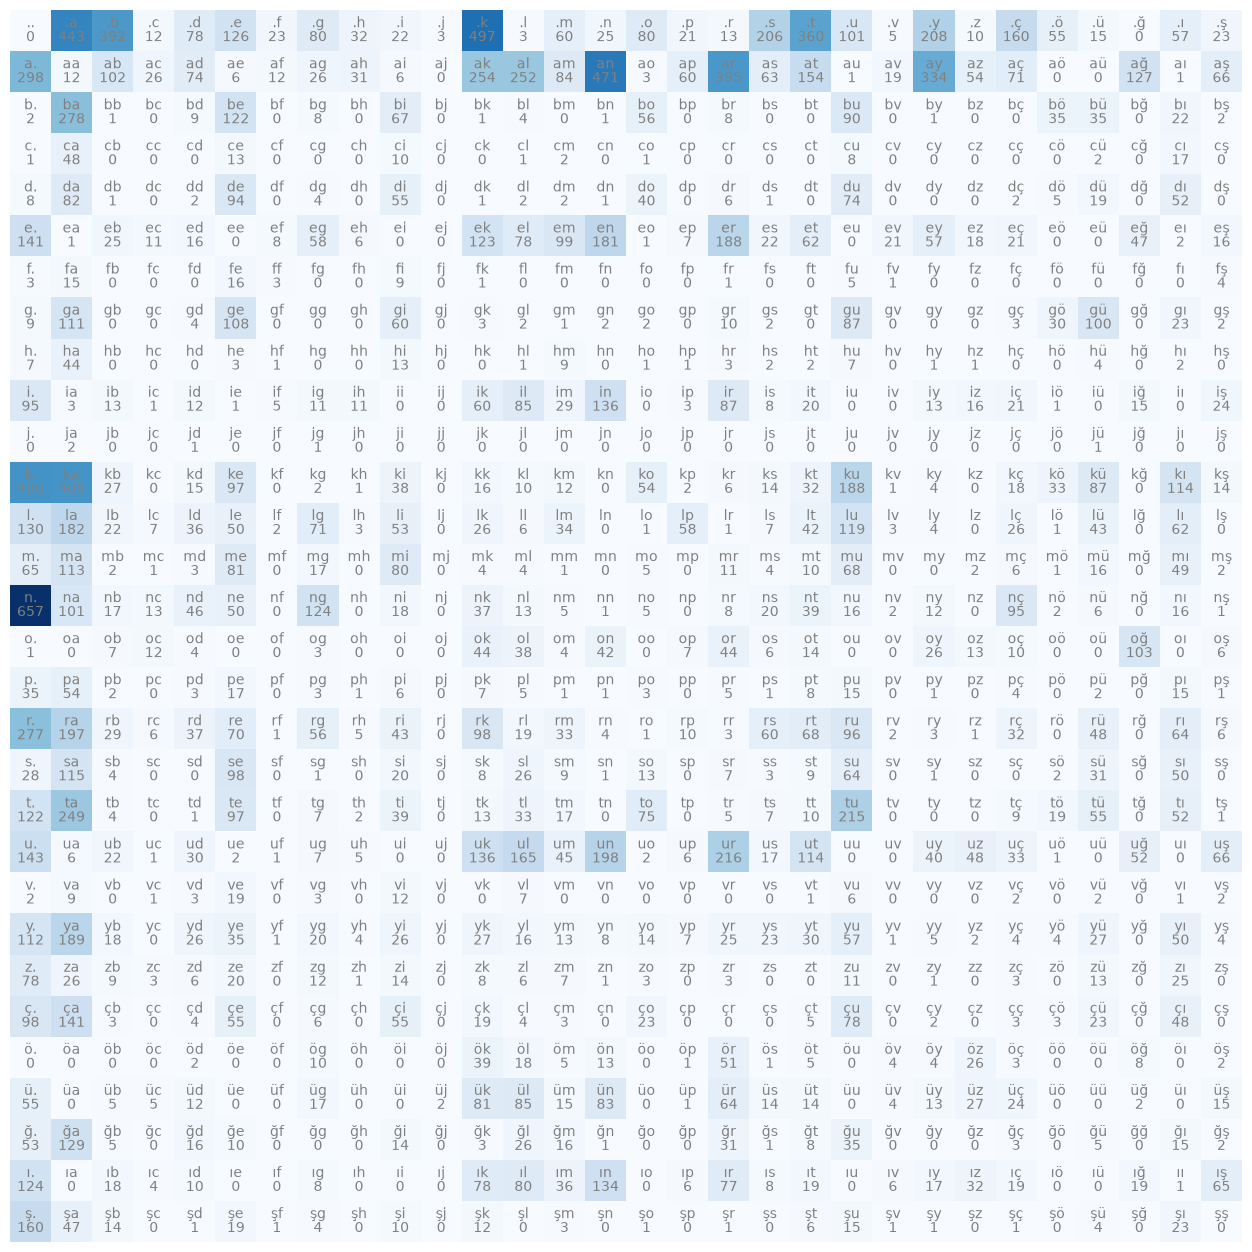

In [164]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize = (16, 16))
plt.imshow(N , cmap='Blues')
for i in range(30):
    for j in range(30):
        chstr = itos[i] + itos[j]
        plt.text(j , i, chstr, ha = 'center', va= 'bottom', color='gray')
        plt.text(j, i , N[i , j].item(), ha = 'center' , va = 'top', color = 'gray')

plt.axis('off')

In [165]:
P = (N+1).float() 
P = P / P.sum(1, keepdim=True)
print(P.shape)
P.sum(1, keepdim=True).shape
print(P.sum(1).shape)

torch.Size([30, 30])
torch.Size([30])


In [166]:
g = torch.Generator().manual_seed(22)
generated = []
for i in range(50):
    out = []
    ix = 0
    while True:
        p = P[ix]   
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    name = (''.join(out))
    print(name)
    generated.append(name)

bak.
yaızs.
ba.
slmik.
s.
a.
tangduzgura.
cıkahz.
çk.
daçandevapı.
ta.
an.
mbeyulangü.
bikunybesak.
tgan.
kay.
andophaya.
k.
hay.
balarüşegin.
yırıpan.
narerabungi.
ksık.
alalukan.
ayzörki.
tögeumınkayerbayan.
akeyevüpa.
sışayar.
tanış.
apayfvelp.
k.
bek.
kuğrkihakoyapfhsoğayalmomalmamangutukıkükdınş.
ekuto.
tbahkadngutanenedutalenatüklibergan.
y.
sün.
depçdı.
üz.
y.
asatöl.
k.
kbakülümey.
tan.
brmı.
çbdutm.
musu.
tvça.
kçuözulbul.
a.


In [167]:
new_names = [n for n in generated if n.replace('.', '') not in words]
already_existing = [n for n in generated if n.replace('.', '') in words]

print("Yeni isimler:")
print(new_names)

print("\nZaten var olan gerçek isimler:")
print(already_existing)

Yeni isimler:
['bak.', 'yaızs.', 'ba.', 'slmik.', 's.', 'a.', 'tangduzgura.', 'cıkahz.', 'çk.', 'daçandevapı.', 'ta.', 'an.', 'mbeyulangü.', 'bikunybesak.', 'tgan.', 'andophaya.', 'k.', 'hay.', 'balarüşegin.', 'yırıpan.', 'narerabungi.', 'ksık.', 'alalukan.', 'ayzörki.', 'tögeumınkayerbayan.', 'akeyevüpa.', 'sışayar.', 'tanış.', 'apayfvelp.', 'k.', 'kuğrkihakoyapfhsoğayalmomalmamangutukıkükdınş.', 'ekuto.', 'tbahkadngutanenedutalenatüklibergan.', 'y.', 'sün.', 'depçdı.', 'üz.', 'y.', 'asatöl.', 'k.', 'kbakülümey.', 'brmı.', 'çbdutm.', 'musu.', 'tvça.', 'kçuözulbul.', 'a.']

Zaten var olan gerçek isimler:
['kay.', 'bek.', 'tan.']


In [168]:
log_likelihood = 0.0
n = 0.0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs [1:]) :
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2] 
        logprob = torch.log(prob) 
        log_likelihood += logprob
        n += 1
nll = -log_likelihood
print(f'loss: {nll/n = }') #loss

loss: nll/n = tensor(2.4546)


In [169]:
#create the dataset
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)  
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement() 
print('number of examples in the dataset:', num)


g = torch.Generator().manual_seed(22)
W = torch.randn((30, 30), generator=g, requires_grad=True)

number of examples in the dataset: 22995


In [175]:
#gradient descent
import torch.nn.functional as F

for k in range(20):
    xenc = F.one_hot(xs, num_classes = 30).float() 
    logits = xenc @ W 
    counts = logits.exp() 
    probs = counts / counts.sum(1, keepdim = True) 
    loss = -probs[torch.arange(num), ys].log().mean() 
    print(loss.item())

    #backward pass
    W.grad = None # gradientleri sıfırlıyoruz
    loss.backward() 


    #update
    W.data += -1.0 * W.grad 
    

2.4433140754699707
2.4433140754699707
2.4433140754699707
2.4433140754699707
2.4433140754699707
2.4433140754699707
2.4433140754699707
2.4433140754699707
2.4433140754699707
2.4433140754699707
2.4433140754699707
2.4433138370513916
2.4433138370513916
2.4433138370513916
2.4433138370513916
2.4433138370513916
2.4433138370513916
2.4433138370513916
2.4433138370513916
2.4433138370513916


In [176]:
print(f'Sayım modeli loss: {nll/n:.4f}')
print(f'Sinir ağı loss: {loss.item():.4f}')

Sayım modeli loss: 2.4546
Sinir ağı loss: 2.4433


In [177]:
g = torch.Generator().manual_seed(22)

for i in range(20):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=30).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out)) # en sonki çıktı loss 2.44 

bak.
yaızgara.
slmik.
s.
a.
tangduzgura.
cıkahz.
çk.
daçandevapı.
ta.
an.
mattulangü.
bikunybesak.
tgan.
kay.
andop.
kuy.
k.
hay.
balarüşegin.


In [ ]:
#ilk çıktı: loss 3.07
'''
fğuşejıssvba.
sşmbk.
s.
guraügjüagjurocdgrhzzlkjdaçspddvöpzvra.
an.
mbeypcangüıhtfuvybescamagmn.
kaybandophğyanh.
htş.
çalarüıeeğjeyı.
bpcn.
njzerabhzöu.
şsşkzöjhıufnen.
yzönziçtpgzuüsikayçpvn.
aıngvefevüdüelısöuşr.
tucışvnvyofvjüakıkbhcçjpğooyanioyaüfhscççgğamomjlmımanğtoğftohıd.
aşr.
ecto.
tbhhfuşncdgmçenrdutplnüsöralibehtgvt.
ğrügpcejçdı.
üçpıkaşşuş.
'''